In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [21]:
# Прочитайте данные (переменную назовите 'df')
df = pd.read_csv('data.csv')

# Вывести несколько первых строк таблицы данных
print(df.head())

         Дата  Склад Контрагент Номенклатура  Количество
0  2018-01-04      1  address_0    product_0           4
1  2018-01-04      1  address_0    product_1           4
2  2018-01-04      1  address_0    product_2           5
3  2018-01-04      1  address_0    product_3          10
4  2018-01-04      1  address_0    product_4           2


Проверяем формат столбцов

In [22]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 301355 entries, 0 to 301354
Data columns (total 5 columns):
 #   Column        Non-Null Count   Dtype 
---  ------        --------------   ----- 
 0   Дата          301355 non-null  object
 1   Склад         301355 non-null  int64 
 2   Контрагент    301355 non-null  object
 3   Номенклатура  301355 non-null  object
 4   Количество    301355 non-null  int64 
dtypes: int64(2), object(3)
memory usage: 11.5+ MB


Сразу переведем столбец "Дата" в правильный формат

In [23]:
df['Дата'] = pd.to_datetime(df['Дата'])
print(df.dtypes)

Дата            datetime64[ns]
Склад                    int64
Контрагент              object
Номенклатура            object
Количество               int64
dtype: object


Сгруппируйте данные по дате, посчитайте количество продаж

In [24]:
grouped_df = df.groupby('Дата')['Количество'].sum().reset_index()

Вывести несколько первых строк сгруппированных данных

In [25]:
print(grouped_df.head())

        Дата  Количество
0 2018-01-04        3734
1 2018-01-05        3643
2 2018-01-06        3193
3 2018-01-07        3298
4 2018-01-09        4055


Нарисуйте график продаж у `grouped_df`

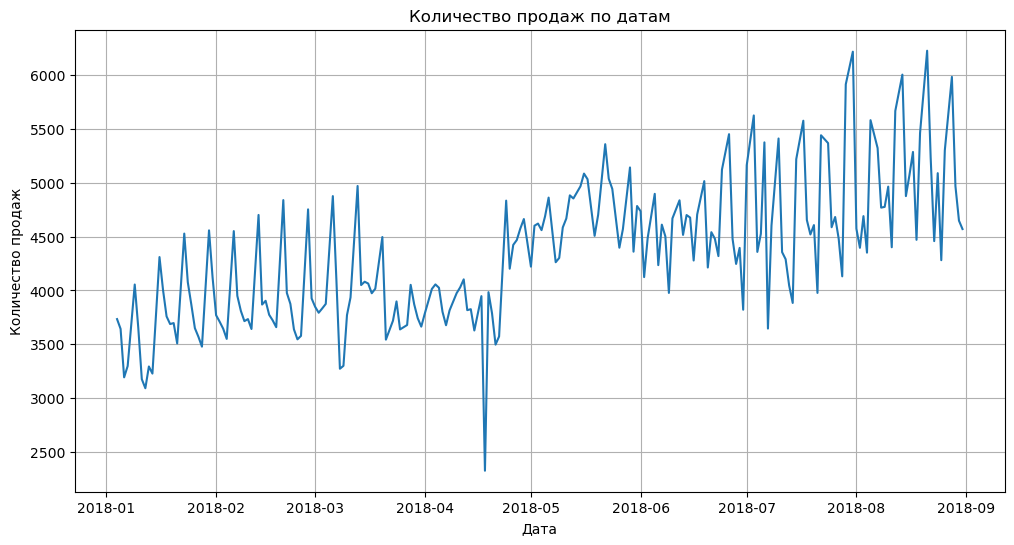

In [26]:
plt.figure(figsize=(12,6))

plt.plot(
    grouped_df['Дата'],
    grouped_df['Количество']
)

plt.title("Количество продаж по датам")
plt.xlabel('Дата')
plt.ylabel('Количество продаж')

plt.grid(True)
plt.show()

Опишите что вы видите на графике. Ваша задача - максимально описать график

На графике представлена динамика количества продаж по дням за период с января по август 2018 года. В течение всего периода наблюдаются регулярные колебания спроса, что может свидетельствовать о наличии недельной сезонности.
В начале года объём продаж находился в диапазоне примерно от 3200 до 4500 единиц. Начиная с мая наблюдается рост продаж, а средний уровень спроса увеличивается до 4500–5500.
На графике видно резкое снижение продаж в конце апреля, где показатель опускается примерно до 2300. Данное значение является выбросом и отличается от других показателей.
Максимальные значения продаж наблюдаются в июле и августе, когда объём достигает более 6000 единиц. Это может указывать на сезонное увеличение спроса или проведение каких либо мероприятий.
Тем не менее график показывает положительный тренд: к концу  периода количество продаж заметно выше, чем в начале года, что свидетельствует о росте спроса на продукцию компании.

Найдите строку, у которой максимальный выброс по количеству продаж (нужно найти выброс у `df`)

In [27]:
max_row = df.loc[df['Количество'].idxmax()]
print(max_row)

Дата            2018-06-28 00:00:00
Склад                             1
Контрагент              address_208
Номенклатура              product_0
Количество                      200
Name: 218822, dtype: object


Найдите топовый товар по продажам по средам за июнь, июль, август у 3 склада

In [28]:
summer_df = df[
    (df['Склад'] == 3) &
    (df['Дата'].dt.month.isin([6,7,8])) &
    (df['Дата'].dt.dayofweek == 2)
]

In [29]:
top_product = (
    summer_df
    .groupby('Номенклатура')['Количество']
    .sum()
    .sort_values(ascending=False))

print(top_product.head())

Номенклатура
product_1    2267
product_2    2060
product_0    1324
product_3     914
product_6     650
Name: Количество, dtype: int64


In [30]:
print(top_product.idxmax())

product_1


Скачайте данные по погоде с https://rp5.ru/Архив_погоды_в_Астане (скачайте исходные данные, и далее преобразуйте так, чтобы мы имели Дату и Среднюю температуру за день), объедините таблицу температуры с `grouped_df`, и нарисуйте график `y=['Количество продаж', 'T']`, где Т это температура. А также отдельно график температуры.

In [50]:
weather = pd.read_csv(
    'weather.csv',
    sep=';',
    skiprows=6
)

print(weather.head())
print(weather.columns)

                  Местное время в Астане      T     Po    P    Pa  \
31.08.2018 23:00                     8.2  736.6  768.3  0.2  78.0   
31.08.2018 20:00                     9.6  736.4  767.9  1.2  88.0   
31.08.2018 17:00                    11.3  735.2  766.4  0.4  83.0   
31.08.2018 14:00                    12.3  734.8  765.9  0.9  80.0   
31.08.2018 11:00                    13.2  733.9  764.8  1.0  83.0   

                                                       U  DD  Ff  ff10  \
31.08.2018 23:00          Ветер, дующий с северо-востока   4 NaN   NaN   
31.08.2018 20:00    Ветер, дующий с западо-северо-запада   3 NaN   NaN   
31.08.2018 17:00  Ветер, дующий с востоко-северо-востока   4 NaN   NaN   
31.08.2018 14:00          Ветер, дующий с северо-востока   4 NaN   NaN   
31.08.2018 11:00   Ветер, дующий с северо-северо-востока   4 NaN   NaN   

                                        ff3  ...  \
31.08.2018 23:00                  70 – 80%.  ...   
31.08.2018 20:00  90  или более, но 

In [52]:
weather = weather.reset_index()
print(weather.head())

              index  Местное время в Астане      T     Po    P    Pa  \
0  31.08.2018 23:00                     8.2  736.6  768.3  0.2  78.0   
1  31.08.2018 20:00                     9.6  736.4  767.9  1.2  88.0   
2  31.08.2018 17:00                    11.3  735.2  766.4  0.4  83.0   
3  31.08.2018 14:00                    12.3  734.8  765.9  0.9  80.0   
4  31.08.2018 11:00                    13.2  733.9  764.8  1.0  83.0   

                                        U  DD  Ff  ff10  ...  \
0          Ветер, дующий с северо-востока   4 NaN   NaN  ...   
1    Ветер, дующий с западо-северо-запада   3 NaN   NaN  ...   
2  Ветер, дующий с востоко-северо-востока   4 NaN   NaN  ...   
3          Ветер, дующий с северо-востока   4 NaN   NaN  ...   
4   Ветер, дующий с северо-северо-востока   4 NaN   NaN  ...   

                                                  Cm    Ch    VV  \
0  Перистых, перисто-кучевых или перисто-слоистых...   NaN   4.6   
1  Перистых, перисто-кучевых или перисто-слоис

In [53]:
print(weather.columns.tolist())

['index', 'Местное время в Астане', 'T', 'Po', 'P', 'Pa', 'U', 'DD', 'Ff', 'ff10', 'ff3', 'N', 'WW', 'W1', 'W2', 'Tn', 'Tx', 'Cl', 'Nh', 'H', 'Cm', 'Ch', 'VV', 'Td', 'RRR', 'tR', 'E', 'Tg', "E'", 'sss']


In [54]:
weather['ДатаВремя'] = pd.to_datetime(
    weather['index'],
    format='%d.%m.%Y %H:%M'
)

weather['Дата'] = weather['ДатаВремя'].dt.date

In [55]:
temp_df = (
    weather.groupby('Дата')['Местное время в Астане']
    .mean()
    .reset_index()
)

temp_df.columns = ['Дата', 'Температура']

print(temp_df.head())

         Дата  Температура
0  2018-01-01      -9.4625
1  2018-01-02      -9.5125
2  2018-01-03     -11.4625
3  2018-01-04     -14.0750
4  2018-01-05     -16.8625


In [57]:
print(grouped_df.columns)

Index(['Дата', 'Количество'], dtype='object')


In [58]:
grouped_df['Дата'] = pd.to_datetime(grouped_df['Дата']).dt.date

result = pd.merge(
    grouped_df,
    temp_df,
    on='Дата',
    how='inner'
)

print(result.head())

         Дата  Количество  Температура
0  2018-01-04        3734     -14.0750
1  2018-01-05        3643     -16.8625
2  2018-01-06        3193     -13.3000
3  2018-01-07        3298     -12.7500
4  2018-01-09        4055      -6.2500


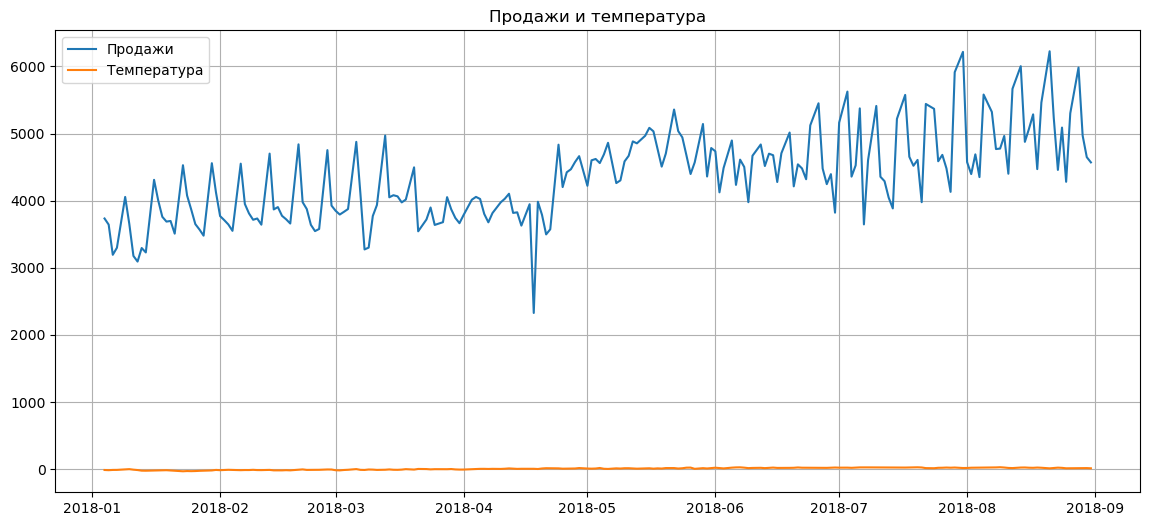

In [59]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14,6))

plt.plot(
    result['Дата'],
    result['Количество'],
    label='Продажи'
)

plt.plot(
    result['Дата'],
    result['Температура'],
    label='Температура'
)

plt.legend()
plt.grid(True)
plt.title('Продажи и температура')

plt.show()

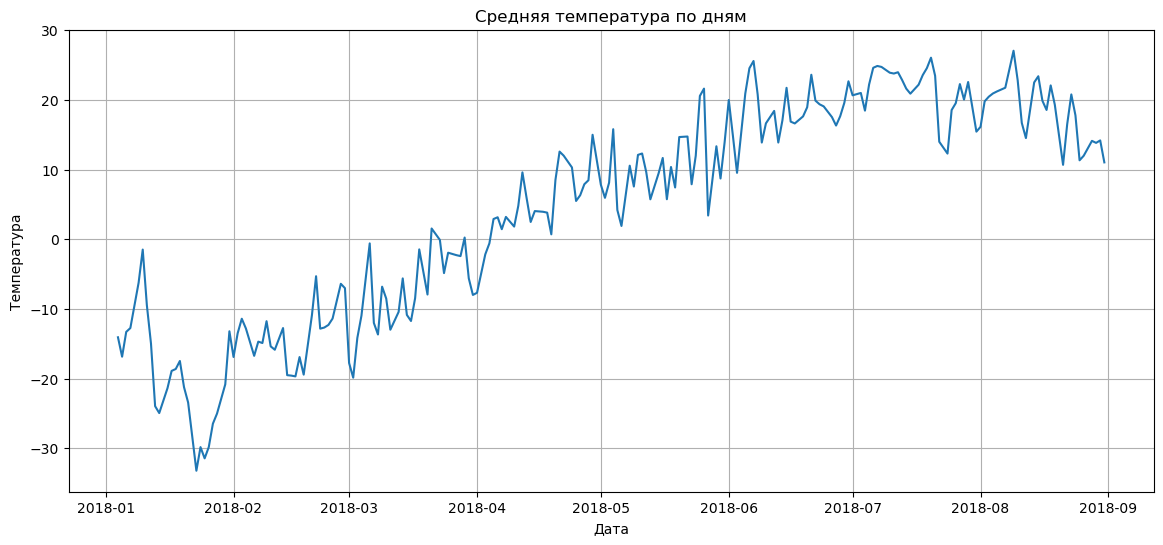

In [60]:
plt.figure(figsize=(14,6))

plt.plot(
    result['Дата'],
    result['Температура']
)

plt.title('Средняя температура по дням')
plt.xlabel('Дата')
plt.ylabel('Температура')

plt.grid(True)
plt.show()

Температура изменяется сезонно. Минимальные значения наблюдаются зимой, максимальные летом. 